In [43]:
import os
import numpy as np
from skimage import io, img_as_float, transform
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import scipy
from scipy import signal
import pandas as pd
import glob

plt.style.use('styleNB.mplstyle')

# Figure 3 related

The bulk of analysis was performed using the ImageJ Adapt plugin (Barry et al., Journal of Cell Biology 209, no. 1 (2015): 163–80. https://doi.org/10.1083/jcb.201501081) as described in the manuscript text. Here we summarize the kymograph data to generate the plots in the main text. 


## Average Galvanin signal

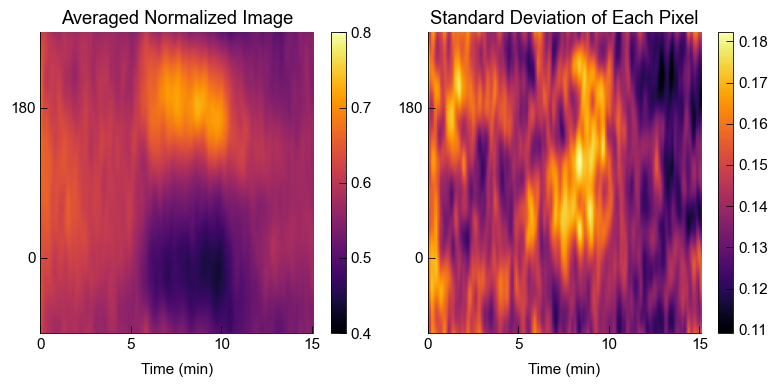

In [71]:
# Directory containing all the images
directory_path = ('/Volumes/ExpansionHomesA/Amy/Galvanin_data/Kymographs/Signals')

# Get a list of all image files in the directory
image_files = [f for f in os.listdir(directory_path) if f.endswith('.tif')]

# Load the first image to get dimensions
first_image_path = os.path.join(directory_path, image_files[0])
first_image = io.imread(first_image_path)
first_image = img_as_float(first_image)

# Define target dimensions
target_height, target_width = 360, 181

# Initialize an array to store normalized pixel intensities
normalized_pixel_intensity_sum = np.zeros((target_height, target_width), dtype=np.float64)

# array holder for calculating std
std_normalized_pixel_intensity = np.zeros((len(image_files), target_height, target_width))

# Iterate through each image
for i, image_file in enumerate(image_files):
    # Load the original image
    image_path = os.path.join(directory_path, image_file)
    image = io.imread(image_path)
    image = img_as_float(image)

    # Normalize intensities
    normalized_image = image / image.max()

    # Resize image to target dimensions
    resized_image = transform.resize(normalized_image, (target_height, target_width))

    # Add normalized pixel intensities to the sum
    normalized_pixel_intensity_sum += resized_image

    std_normalized_pixel_intensity[i] = resized_image

# Calculate the average normalized pixel intensity
average_normalized_pixel_intensity = normalized_pixel_intensity_sum / len(image_files)

# # Calculate the standard deviation of each pixel across all images
# pixel_std_deviation = np.std([transform.resize(img_as_float(io.imread(os.path.join(directory_path, f))), #[:, 0:120],
#                                                 (target_height, target_width))
#                               for f in image_files], axis=0, dtype=np.float64)

pixel_std_deviation = np.std(std_normalized_pixel_intensity, axis = 0)

# Create meshgrid for x-coordinates
x_coordinates = np.arange(1, target_width+1)

# Create meshgrid for normalized y-coordinates
normalized_y = np.linspace(0, 360, target_height)[:, np.newaxis]
x_mesh, y_mesh = np.meshgrid(x_coordinates, normalized_y)

# Plot the averaged normalized image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(average_normalized_pixel_intensity, vmax = 0.8, vmin = 0.4, cmap='inferno', aspect='auto',
           extent=[0, target_width/ 12, -90, 270])
plt.title('Averaged Normalized Image')
plt.yticks(np.arange(0, 181, step=180))
plt.xticks(np.arange(0, 16, step=5))
plt.xlabel('Time (min)')
plt.colorbar(ticks=[0.4, 0.5, 0.6, 0.7, 0.8])

# cmap='inferno'

# Plot the standard deviation of each pixel
plt.subplot(1, 2, 2)
plt.imshow(pixel_std_deviation, cmap='inferno', aspect='auto', 
           extent=[0, target_width/ 12, -90, 270])
plt.title('Standard Deviation of Each Pixel')
plt.yticks(np.arange(0, 181, step=180))
plt.xticks(np.arange(0, 16, step=5))
plt.xlabel('Time (min)')
plt.colorbar()

plt.tight_layout()

In [72]:
# Define some useful position ranges for the front and back
# Because the pixels are defined with 0 at top and 360 at bottom (inverse of graphed), use these values
# Front y-values
degree_60 = 240
degree_120 = 300
# Back y-values
degree_240 = 60
degree_300 = 120

off_x_value = 0
on_x_value = 120

# Save values to another variable name
gfp_kymograph = average_normalized_pixel_intensity
gfp_kymo_std_dev = pixel_std_deviation

# gfp_avg_front = np.mean(average_normalized_pixel_intensity[330-90:330,:121].T, axis = 1)

In [77]:
gfp_kymo_std_dev

array([[0.15614199, 0.14988251, 0.1630317 , ..., 0.15473727, 0.14784049,
        0.15251044],
       [0.15638257, 0.14989696, 0.16260459, ..., 0.15384569, 0.14707632,
        0.15166289],
       [0.15664277, 0.14992583, 0.16217829, ..., 0.15293304, 0.14628909,
        0.15078762],
       ...,
       [0.14899734, 0.1514641 , 0.16274753, ..., 0.14967973, 0.14663406,
        0.15215755],
       [0.14920805, 0.15154352, 0.16300101, ..., 0.15059155, 0.14731932,
        0.1527754 ],
       [0.14943232, 0.15163074, 0.16326788, ..., 0.15149041, 0.1479808 ,
        0.15336635]])

## Protrusion/retraction 'signal'

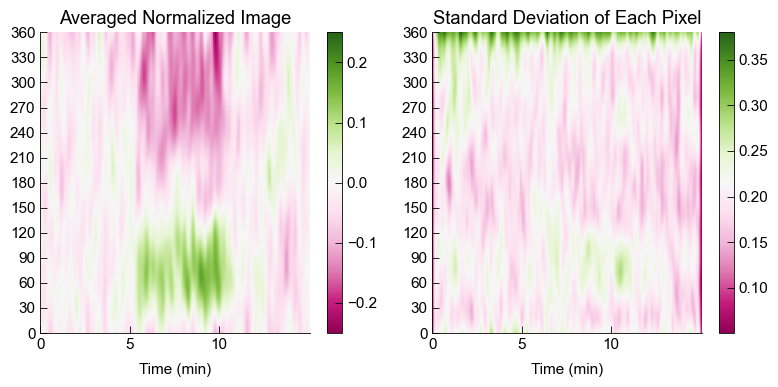

In [67]:
# Directory containing all the velocity kymographs
directory_path = '/Volumes/ExpansionHomesA/Amy/Galvanin_data/Kymographs/Velocity'

# Set vmax, -vmax for velocity plots
v_max = 3/12

# Get a list of all image files in the directory
image_files = [f for f in os.listdir(directory_path) if f.endswith('.tif')]

# Load the first image to get dimensions
first_image_path = os.path.join(directory_path, image_files[0])
first_image = io.imread(first_image_path)
first_image = img_as_float(first_image)

# Define target dimensions
# target_height, target_width = 360, 121
target_height, target_width = 360, 181

# Initialize an array to store normalized pixel intensities
normalized_pixel_intensity_sum = np.zeros((target_height, target_width), dtype=np.float64)

# array holder for calculating std
std_normalized_pixel_intensity = np.zeros((len(image_files), target_height, target_width))
                                          
# Iterate through each image
for i, image_file in enumerate(image_files):
    # Load the original image
    image_path = os.path.join(directory_path, image_file)
    image = io.imread(image_path)
    image = img_as_float(image)

    # Resize image to target dimensions
    resized_image = transform.resize(image, (target_height, target_width))

    # Add normalized pixel intensities to the sum
    normalized_pixel_intensity_sum += resized_image

    std_normalized_pixel_intensity[i] = resized_image

# Calculate the average normalized pixel intensity
average_normalized_pixel_intensity = normalized_pixel_intensity_sum / len(image_files)

# # Calculate the standard deviation of each pixel across all images
# pixel_std_deviation = np.std([transform.resize(img_as_float(io.imread(os.path.join(directory_path, f))),#[:, 0:120],
#                                                 (target_height, target_width))
#                               for f in image_files], axis=0, dtype=np.float64)

pixel_std_deviation = np.std(std_normalized_pixel_intensity, axis = 0)

# Create meshgrid for x-coordinates
x_coordinates = np.arange(1, target_width+1)

# Create meshgrid for normalized y-coordinates
normalized_y = np.linspace(0, 360, target_height)[:, np.newaxis]
x_mesh, y_mesh = np.meshgrid(x_coordinates, normalized_y)

# Plot the averaged normalized image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(average_normalized_pixel_intensity, vmax=v_max, vmin = -v_max, 
           cmap='PiYG', aspect='auto', extent=[0, target_width/ 12, 0, 360])
plt.title('Averaged Normalized Image')
plt.yticks(np.arange(0, 361, step=30))
plt.xticks(np.arange(0, 11, step=5))
plt.xlabel('Time (min)')
plt.colorbar()

# Plot the standard deviation of each pixel
plt.subplot(1, 2, 2)
plt.imshow(pixel_std_deviation, cmap='PiYG', aspect='auto',
           extent=[0, target_width/12, 0, 360])
plt.title('Standard Deviation of Each Pixel')
plt.yticks(np.arange(0, 361, step=30))
plt.xticks(np.arange(0, 11, step=5))
plt.xlabel('Time (min)')
plt.colorbar()

plt.tight_layout()


In [70]:
# Save values to another variable name
v_kymograph = average_normalized_pixel_intensity
v_kymo_std_dev = pixel_std_deviation


# v_avg_front = np.mean(average_normalized_pixel_intensity[degree_60:degree_120,:121].T, axis = 1)
# v_std_front = np.mean(v_kymo_std_dev[degree_60:degree_120,:121].T, axis = 1)

## Generate single cell example

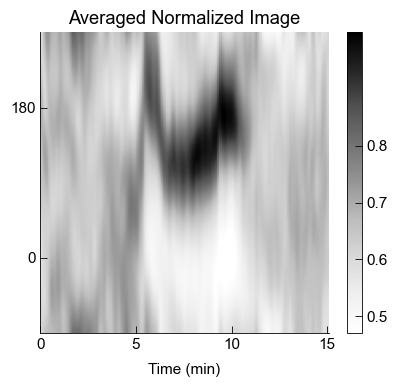

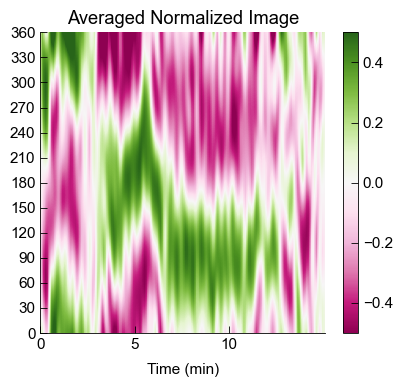

In [33]:
image_files_sig = ['20240213_10_cell9_SignalMap.tif']
image_files_vel = ['20240213_10_cell9_VelocityMap.tif']



image_files = image_files_sig

# Directory containing all the images
directory_path = ('/Volumes/ExpansionHomesA/Amy/Galvanin_data/Kymographs/Signals')

# Load the first image to get dimensions
first_image_path = os.path.join(directory_path, image_files[0])
first_image = io.imread(first_image_path)
first_image = img_as_float(first_image)

# Define target dimensions
target_height, target_width = 360, 181

# Initialize an array to store normalized pixel intensities
normalized_pixel_intensity_sum = np.zeros((target_height, target_width), dtype=np.float64)

# Iterate through each image
for image_file in image_files:
    # Load the original image
    image_path = os.path.join(directory_path, image_file)
    image = io.imread(image_path)
    image = img_as_float(image)

    # Normalize intensities
    normalized_image = image / image.max()

    # Resize image to target dimensions
    resized_image = transform.resize(normalized_image, (target_height, target_width))

    # Add normalized pixel intensities to the sum
    normalized_pixel_intensity_sum += resized_image

# Calculate the average normalized pixel intensity
average_normalized_pixel_intensity = normalized_pixel_intensity_sum / len(image_files)

# Calculate the standard deviation of each pixel across all images
pixel_std_deviation = np.std([transform.resize(img_as_float(io.imread(os.path.join(directory_path, f))), #[:, 0:120],
                                                (target_height, target_width))
                              for f in image_files], axis=0, dtype=np.float64)

# Create meshgrid for x-coordinates
x_coordinates = np.arange(1, target_width+1)

# Create meshgrid for normalized y-coordinates
normalized_y = np.linspace(0, 360, target_height)[:, np.newaxis]
x_mesh, y_mesh = np.meshgrid(x_coordinates, normalized_y)

# Plot the averaged normalized image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
# plt.imshow(average_normalized_pixel_intensity, vmax = 0.8, vmin = 0.4, cmap='inferno', aspect='auto',
#            extent=[0, target_width/ 12, -90, 270])
plt.imshow(average_normalized_pixel_intensity, vmax= 1, vmin = 0.47, 
           cmap='Greys', aspect='auto', 
                     extent=[0, target_width/ 12, -90, 270])

gfp_kymograph = average_normalized_pixel_intensity
plt.title('Averaged Normalized Image')
plt.yticks(np.arange(0, 181, step=180))
plt.xticks(np.arange(0, 16, step=5))
plt.xlabel('Time (min)')
plt.colorbar(ticks=[0.4, 0.5, 0.6, 0.7, 0.8])

# cmap='inferno'

# # Plot the standard deviation of each pixel
# plt.subplot(1, 2, 2)
# plt.imshow(pixel_std_deviation, cmap='inferno', aspect='auto', 
#            extent=[0, target_width/ 12, -90, 270])
# plt.title('Standard Deviation of Each Pixel')
# plt.yticks(np.arange(0, 181, step=180))
# plt.xticks(np.arange(0, 16, step=5))
# plt.xlabel('Time (min)')
# plt.colorbar()


plt.tight_layout()



# Directory containing all the velocity kymographs
directory_path = '/Volumes/ExpansionHomesA/Amy/Galvanin_data/Kymographs/Velocity'

# Set vmax, -vmax for velocity plots
v_max = 3/12

# Get a list of all image files in the directory
image_files = image_files_vel

# Load the first image to get dimensions
first_image_path = os.path.join(directory_path, image_files[0])
first_image = io.imread(first_image_path)
first_image = img_as_float(first_image)

# Define target dimensions
# target_height, target_width = 360, 121
target_height, target_width = 360, 181

# Initialize an array to store normalized pixel intensities
normalized_pixel_intensity_sum = np.zeros((target_height, target_width), dtype=np.float64)

# Iterate through each image
for image_file in image_files:
    # Load the original image
    image_path = os.path.join(directory_path, image_file)
    image = io.imread(image_path)
    image = img_as_float(image)

    # Resize image to target dimensions
    resized_image = transform.resize(image, (target_height, target_width))

    # Add normalized pixel intensities to the sum
    normalized_pixel_intensity_sum += resized_image

# Calculate the average normalized pixel intensity
average_normalized_pixel_intensity = normalized_pixel_intensity_sum / len(image_files)

# Calculate the standard deviation of each pixel across all images
pixel_std_deviation = np.std([transform.resize(img_as_float(io.imread(os.path.join(directory_path, f))),#[:, 0:120],
                                                (target_height, target_width))
                              for f in image_files], axis=0, dtype=np.float64)

# Create meshgrid for x-coordinates
x_coordinates = np.arange(1, target_width+1)

# Create meshgrid for normalized y-coordinates
normalized_y = np.linspace(0, 360, target_height)[:, np.newaxis]
x_mesh, y_mesh = np.meshgrid(x_coordinates, normalized_y)

# Plot the averaged normalized image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
v_max = 0.5
plt.imshow(average_normalized_pixel_intensity, vmax=v_max, vmin = -v_max, 
           cmap='PiYG', aspect='auto', extent=[0, target_width/ 12, 0, 360])
v_kymograph = average_normalized_pixel_intensity
plt.title('Averaged Normalized Image')
plt.yticks(np.arange(0, 361, step=30))
plt.xticks(np.arange(0, 11, step=5))
plt.xlabel('Time (min)')
plt.colorbar()



plt.tight_layout()





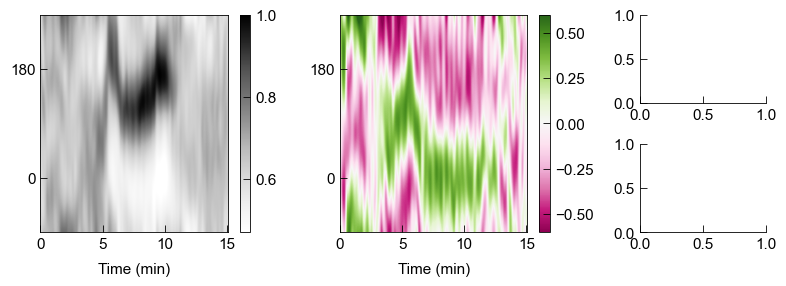

In [41]:
# Create a figure
fig = plt.figure(figsize=(8, 3))

# Create a GridSpec with 2 rows and 3 columns
gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 1.5], height_ratios=[1, 1])

# Add subplots
ax1 = fig.add_subplot(gs[:, :2])  # First row, first column
ax2 = fig.add_subplot(gs[:, 2:4])  # First row, span across second and third columns
ax3 = fig.add_subplot(gs[0, 4])  # Second row, span across first and second columns
ax4 = fig.add_subplot(gs[1, 4])  # Second row, third column

target_height, target_width = 360, 181
v_max = 0.8
v_min = 0.4

img_gfp = ax1.imshow(gfp_kymograph, vmax= 1, vmin = 0.47, 
           cmap='Greys', aspect='auto', 
                     extent=[0, target_width/ 12, -90, 270])
ax1.set_yticks(np.arange(0, 181, step=180))
# ax1.set_yticks(np.arange(0, 361, step=30))
ax1.set_xticks(np.arange(0, 16, step=5))
ax1.set_xlabel('Time (min)')


# Add colorbar to ax2
cbar = fig.colorbar(img_gfp, ax=ax1, orientation='vertical',
                   ticks = [0.4, 0.6, 0.8, 1.0])

# Set vmax, -vmax for velocity plots
v_max = 0.6

img_v = ax2.imshow(v_kymograph, vmax=v_max, vmin = -v_max, 
           cmap='PiYG', aspect='auto', 
                     extent=[0, target_width/ 12, -90, 270])
ax2.set_yticks(np.arange(0, 181, step=180))
ax2.set_xticks(np.arange(0, 16, step=5))
ax2.set_xlabel('Time (min)')
# Add colorbar to ax2
cbar = fig.colorbar(img_v, ax=ax2, orientation='vertical',
                   ticks = [-0.5, -0.25 ,0 , 0.25, 0.5])


ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)

ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)

# x = np.arange(121)*5/60
# ax3.plot(x, gfp_avg_front, color = c_inferno[0])
# ax3.plot(x, gfp_avg_rear, color = c_inferno[-4])
# ax3.set_ylim(0.4,0.8)
# ax3.set_xlim(0,10)
# ax3.set_xticks(np.arange(0, 11, step=5))
# ax3.set_xlabel('Time (min)')

# ax4.plot(x, v_avg_front, color = c_PiYG[-1])
# ax4.plot(x, v_avg_rear, color = c_PiYG[0])
# ax4.set_ylim(-2/12,2/12)
# ax4.set_xlim(0,10)
# ax4.set_xticks(np.arange(0, 11, step=5))
# ax4.set_xlabel('Time (min)')


plt.tight_layout()

fig.savefig('../../figures/20240924_Fig4_singlecell_example.pdf')

array([0.0753575 , 0.16549787, 0.20934134, 0.21331979, 0.20964726,
       0.20186011, 0.19622435, 0.2005164 , 0.20345228, 0.20635772,
       0.2133852 , 0.20940867, 0.20871875, 0.2177685 , 0.22686845,
       0.22950664, 0.22058807, 0.20942296, 0.20442967, 0.19453884,
       0.19425276, 0.19759022, 0.19451717, 0.19589315, 0.20108814,
       0.19918738, 0.19589976, 0.19933183, 0.19992162, 0.19455511,
       0.19978442, 0.20566224, 0.19658537, 0.18721321, 0.18481452,
       0.19312932, 0.20519059, 0.20860272, 0.20280015, 0.19416013,
       0.1978369 , 0.20146566, 0.20346104, 0.20884474, 0.21318804,
       0.21522505, 0.21337483, 0.21244093, 0.20895269, 0.20096062,
       0.19450249, 0.18972057, 0.18097009, 0.17975161, 0.1852018 ,
       0.18207812, 0.18223953, 0.18438671, 0.18787647, 0.19586435,
       0.19134947, 0.18278533, 0.18908013, 0.2041278 , 0.20898284,
       0.21070684, 0.21377185, 0.21335795, 0.21274748, 0.20833127,
       0.20226644, 0.2074016 , 0.21102472, 0.20391801, 0.20215

### Summary of Galvanin signal and speed values at front and rear of cell

In [78]:
# Front y-values
degree_60 = 210
degree_120 = 330
# Back y-values
degree_240 = 30
degree_300 = 150

# gfp_kymograph = average_normalized_pixel_intensity
gfp_avg_front = np.mean(gfp_kymograph[degree_60:degree_120,:121].T, axis = 1)
gfp_avg_rear =  np.mean(gfp_kymograph[degree_240:degree_300,:121].T, axis = 1)

# std gfp_kymograph 
gfp_std_front = np.mean(gfp_kymo_std_dev[degree_60:degree_120,:121].T, axis = 1)
gfp_std_rear =  np.mean(gfp_kymo_std_dev[degree_240:degree_300,:121].T, axis = 1)

# v_kymograph = average_normalized_pixel_intensity
v_avg_front = np.mean(v_kymograph[degree_60:degree_120,:121].T, axis = 1)
v_avg_rear = np.mean(v_kymograph[degree_240:degree_300,:121].T, axis = 1)

# std v_kymograph 
v_std_front = np.mean(v_kymo_std_dev[degree_60:degree_120,:121].T, axis = 1)
v_std_rear = np.mean(v_kymo_std_dev[degree_240:degree_300,:121].T, axis = 1)

In [87]:
num_colors = 10

# Get the 'PiYG' colormap
cmap = cm.get_cmap('PiYG', 10)
# Extract the colors
c_PiYG = cmap(range(num_colors))


# # Get the 'PiYG' colormap
# cmap = cm.get_cmap('inferno', 10)
# # Extract the colors
# c_inferno = cmap(range(num_colors))

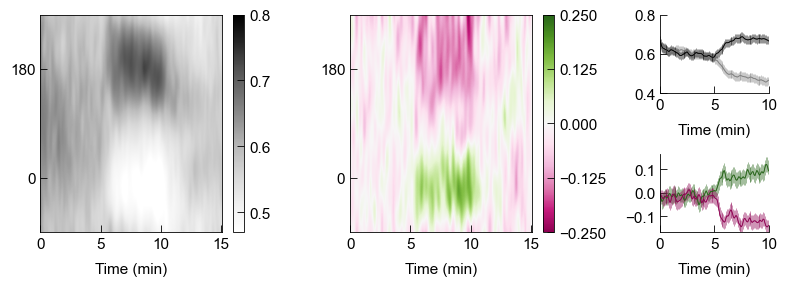

In [86]:
# Create a figure
fig = plt.figure(figsize=(8, 3))

# Create a GridSpec with 2 rows and 3 columns
gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 1.5], height_ratios=[1, 1])

# Add subplots
ax1 = fig.add_subplot(gs[:, :2])  # First row, first column
ax2 = fig.add_subplot(gs[:, 2:4])  # First row, span across second and third columns
ax3 = fig.add_subplot(gs[0, 4])  # Second row, span across first and second columns
ax4 = fig.add_subplot(gs[1, 4])  # Second row, third column

target_height, target_width = 360, 181
v_max = 0.8
v_min = 0.4

img_gfp = ax1.imshow(gfp_kymograph, vmax=0.8, vmin = 0.47, 
           cmap='Greys', aspect='auto', 
                     extent=[0, target_width/ 12, -90, 270])
ax1.set_yticks(np.arange(0, 181, step=180))
# ax1.set_yticks(np.arange(0, 361, step=30))
ax1.set_xticks(np.arange(0, 16, step=5))
ax1.set_xlabel('Time (min)')


# Add colorbar to ax2
cbar = fig.colorbar(img_gfp, ax=ax1, orientation='vertical',
                   ticks = [0.4, 0.5, 0.6,0.7, 0.8])

# Set vmax, -vmax for velocity plots
v_max = 3/12

img_v = ax2.imshow(v_kymograph, vmax=v_max, vmin = -v_max, 
           cmap='PiYG', aspect='auto', 
                     extent=[0, target_width/ 12, -90, 270])
ax2.set_yticks(np.arange(0, 181, step=180))
ax2.set_xticks(np.arange(0, 16, step=5))
ax2.set_xlabel('Time (min)')
# Add colorbar to ax2
cbar = fig.colorbar(img_v, ax=ax2, orientation='vertical',
                   ticks = [-0.25, -0.125 ,0 , 0.125, 0.25])


ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)

ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)

x = np.arange(121)*5/60
ax3.errorbar(x, gfp_avg_front, yerr = gfp_std_front/np.sqrt(46),  color = 'grey', alpha = 0.5)
ax3.errorbar(x, gfp_avg_front, color = 'grey')
ax3.errorbar(x, gfp_avg_rear, yerr = gfp_std_front/np.sqrt(46), color = 'k', alpha = 0.5)
ax3.errorbar(x, gfp_avg_rear, color = 'k')
ax3.set_ylim(0.4,0.8)
ax3.set_xlim(0,10)
ax3.set_xticks(np.arange(0, 11, step=5))
ax3.set_xlabel('Time (min)')

ax4.errorbar(x, v_avg_front, yerr = v_std_front/np.sqrt(46), color = c_PiYG[-1], alpha = 0.5)
ax4.errorbar(x, v_avg_front, color = c_PiYG[-1])
ax4.errorbar(x, v_avg_rear, yerr = v_std_rear/np.sqrt(46), color = c_PiYG[0], alpha = 0.5)
ax4.errorbar(x, v_avg_rear, color = c_PiYG[0])
ax4.set_ylim(-2/12,2/12)
ax4.set_xlim(0,10)
ax4.set_xticks(np.arange(0, 11, step=5))
ax4.set_xlabel('Time (min)')


plt.tight_layout()

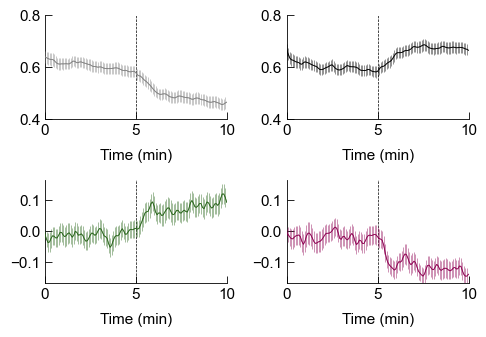

In [105]:
# Create a figure
fig = plt.figure(figsize=(5, 3.5))

# Create a GridSpec with 2 rows and 3 columns
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# Add subplots
ax1 = fig.add_subplot(gs[0,0])  # First row, first column
ax2 = fig.add_subplot(gs[0,1])  # First row, span across second and third columns
ax3 = fig.add_subplot(gs[1,0])  # Second row, span across first and second columns
ax4 = fig.add_subplot(gs[1, 1])  # Second row, third column



x = np.arange(121)*5/60
ax1.errorbar(x, gfp_avg_front, yerr = gfp_std_front/np.sqrt(46),  color = 'grey', alpha = 0.5, zorder = 10)
ax1.errorbar(x, gfp_avg_front, color = 'grey', zorder = 10)
ax2.errorbar(x, gfp_avg_rear, yerr = gfp_std_front/np.sqrt(46), color = 'k', alpha = 0.5, zorder = 10)
ax2.errorbar(x, gfp_avg_rear, color = 'k', zorder = 10)

for ax_ in [ax1, ax2]:
    ax_.set_ylim(0.4,0.8)
    ax_.set_xlim(0,10)
    ax_.set_xticks(np.arange(0, 11, step=5))
    ax_.set_xlabel('Time (min)')
    ax_.vlines(5,-1,1, linewidth = 0.5, color = 'k', linestyle = '--', zorder = 0)

ax3.errorbar(x, v_avg_front, yerr = v_std_front/np.sqrt(46), color = c_PiYG[-1], alpha = 0.5, zorder = 10)
ax3.errorbar(x, v_avg_front, color = c_PiYG[-1], zorder = 10)
ax4.errorbar(x, v_avg_rear, yerr = v_std_rear/np.sqrt(46), color = c_PiYG[0], alpha = 0.5, zorder = 10)
ax4.errorbar(x, v_avg_rear, color = c_PiYG[0], zorder = 10)

for ax_ in [ax3, ax4]:
    ax_.set_ylim(-2/12,2/12)
    ax_.set_xlim(0,10)
    ax_.set_xticks(np.arange(0, 11, step=5))
    ax_.set_xlabel('Time (min)')
    ax_.vlines(5,-1,1, linewidth = 0.5, color = 'k', linestyle = '--', zorder = 0)


plt.tight_layout()
fig.savefig('../../figures/20240924_Fig4_front_back_sig_vel.pdf')